In [1]:
#importing all important libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

In [2]:
#data preprocessing
xls = pd.ExcelFile('online_retail_II.xlsx')
print(xls.sheet_names)
df = pd.concat([pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names], ignore_index=True)
df.to_csv('online_retail_combined.csv', index=False)

['Year 2009-2010', 'Year 2010-2011']


In [3]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.describe())

(1067371, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
           Quantity                    InvoiceDate         Price  \
count  1.067371e+06                        1067371  1.067371e+06   
mean   9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min   -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%    1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%    3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%    1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max    8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std    1.727058e+02                            NaN  1.235531e+02   

         Customer ID  
count  824364.000000  
mean    15324.638504  
min     12346.

In [4]:
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Customer ID'] = df['Customer ID'].astype(int)
print(df.shape)
print(df.describe())

(805549, 8)
            Quantity                    InvoiceDate          Price  \
count  805549.000000                         805549  805549.000000   
mean       13.290522  2011-01-02 10:24:44.106814464       3.206561   
min         1.000000            2009-12-01 07:45:00       0.001000   
25%         2.000000            2010-07-07 12:08:00       1.250000   
50%         5.000000            2010-12-03 15:10:00       1.950000   
75%        12.000000            2011-07-28 13:05:00       3.750000   
max     80995.000000            2011-12-09 12:50:00   10953.500000   
std       143.634088                            NaN      29.199173   

         Customer ID  
count  805549.000000  
mean    15331.954970  
min     12346.000000  
25%     13982.000000  
50%     15271.000000  
75%     16805.000000  
max     18287.000000  
std      1696.737039  


In [5]:
#RFM Feature engineering
df['TotalPrice'] = df['Quantity'] * df['Price']
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()
print(rfm.shape)
print(rfm.describe())

(5878, 4)
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


In [6]:
#Handle skew before scaling
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
print(rfm[['Recency_log','Frequency_log','Monetary_log']].describe())

       Recency_log  Frequency_log  Monetary_log
count  5878.000000    5878.000000   5878.000000
mean      4.454132       1.549588      6.836550
std       1.559404       0.809447      1.387864
min       0.693147       0.693147      1.373716
25%       3.295837       0.693147      5.857254
50%       4.574711       1.386294      6.802300
75%       5.942799       2.079442      7.744175
max       6.606650       5.988961     13.319282


In [11]:
#feature scaling
features=rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)
print(scaled_features[:5])
print(scaled_features.mean(axis=0))
print(scaled_features.std(axis=0))


[[ 0.85670058  1.25449595  3.18662493]
 [-2.15197903  0.80016603  1.2971269 ]
 [-0.07913835  0.29920733  0.55810028]
 [-0.93530818  0.07394609  1.12379048]
 [ 0.82452706 -1.05814595 -0.73588827]]
[-5.05285579e-16  2.38136984e-16 -4.35174183e-16]
[1. 1. 1.]


In [13]:
#testing k values
inertia = []
silhouette_scores = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))
for k, sil in zip(K_range, silhouette_scores):
    print(f"K={k} -> Silhouette: {sil:.4f}")

K=2 -> Silhouette: 0.4381
K=3 -> Silhouette: 0.3478
K=4 -> Silhouette: 0.3653
K=5 -> Silhouette: 0.3421
K=6 -> Silhouette: 0.3336
K=7 -> Silhouette: 0.3052


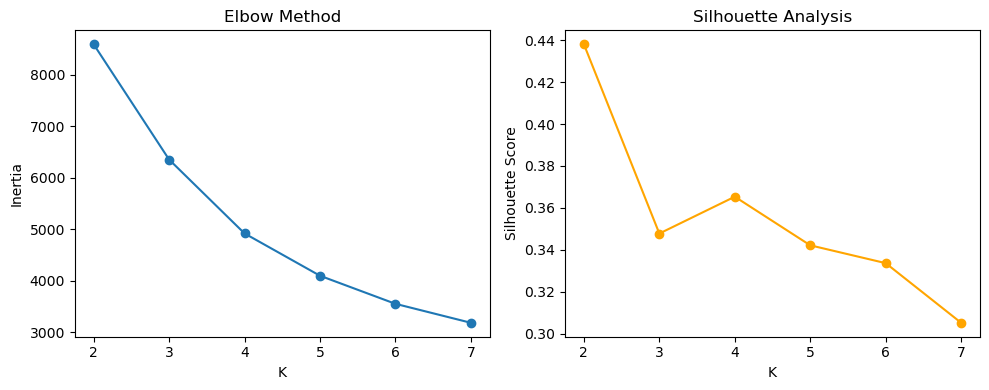

In [15]:
#ploting graphs for silohoute score and inertia
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

In [18]:
#knn model final implementation
kmean_final= KMeans(n_clusters=4,n_init=10,random_state=42)
rfm['Cluster']=kmean_final.fit_predict(scaled_features)
print(rfm['Cluster'].value_counts())

Cluster
1    1974
2    1465
3    1251
0    1188
Name: count, dtype: int64


In [20]:
#Cluster Profiling — Aggregating RFM Metrics per Cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Customer_Count=('Customer ID', 'count')
).reset_index()
cluster_profile['Percentage'] = (cluster_profile['Customer_Count'] / cluster_profile['Customer_Count'].sum() * 100).round(1)
print(cluster_profile)

   Cluster  Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count  \
0        0    27.430976      19.341751  11014.368423            1188   
1        1   395.862715       1.379433    325.748182            1974   
2        2   227.872355       5.098294   2002.102476            1465   
3        3    28.437250       3.036771    865.109874            1251   

   Percentage  
0        20.2  
1        33.6  
2        24.9  
3        21.3  


In [22]:
#pca implementaion
pca=PCA(n_components=2,random_state=42)
pca_result=pca.fit_transform(scaled_features)
rfm['PCA1']=pca_result[:,0]
rfm['PCA2']=pca_result[:,1]
print(pca.explained_variance_ratio_)

[0.76372366 0.18766172]


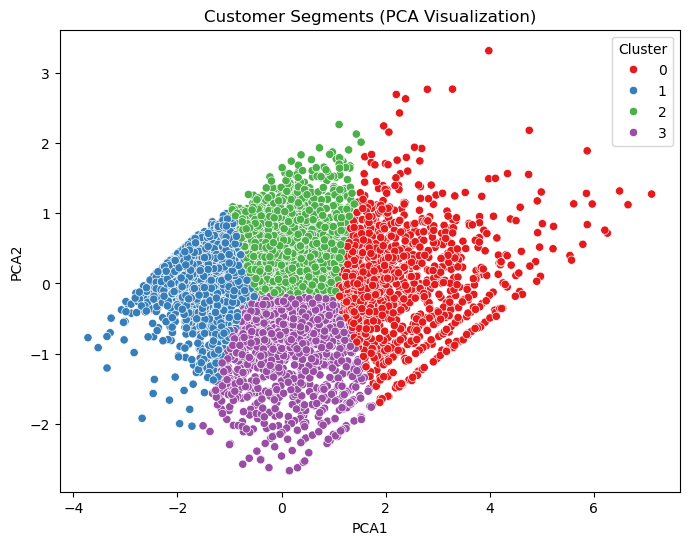

In [24]:
#ploting graphs
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set1')
plt.title('Customer Segments (PCA Visualization)')
plt.show()

In [33]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
rfm['anomaly'] = iso_forest.fit_predict(scaled_features)
rfm['anomaly_score'] = iso_forest.decision_function(scaled_features)
rfm['anomaly'] = rfm['anomaly'].map({1: 'Normal', -1: 'Anomaly'})
print(rfm['anomaly'].value_counts())

anomaly
Normal     5584
Anomaly     294
Name: count, dtype: int64


In [35]:
#inspect anomly
print(rfm.groupby('anomaly')[['Recency','Frequency','Monetary']].mean())

            Recency  Frequency      Monetary
anomaly                                     
Anomaly   91.799320  33.323129  26609.135728
Normal   207.098854   4.866046   1776.565773


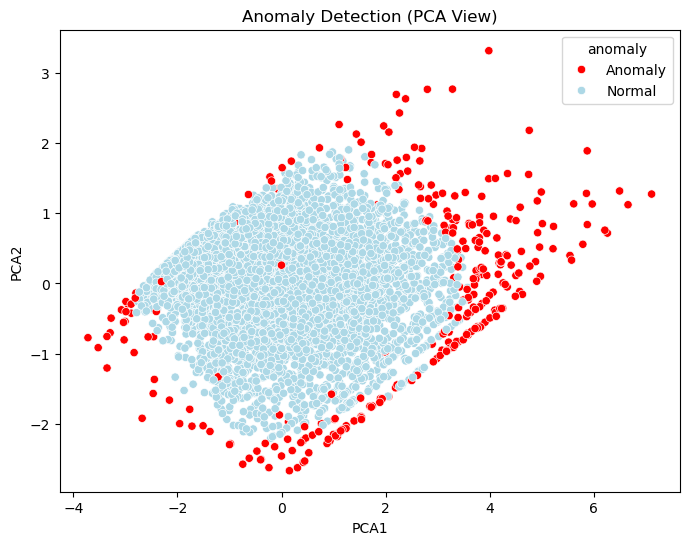

In [37]:
#visulize graph for anomlies
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='anomaly', palette={'Normal':'lightblue','Anomaly':'red'})
plt.title('Anomaly Detection (PCA View)')
plt.show()

In [39]:
#Customer Similarity (KNN)
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(scaled_features)
customer_index = 0
distances, indices = knn.kneighbors([scaled_features[customer_index]])
print(rfm.iloc[indices[0]][['Customer ID','Recency','Frequency','Monetary']])


      Customer ID  Recency  Frequency  Monetary
0           12346      326         12  77556.46
568         12917      128          6   4359.20
3935        16320      172          6   5628.99
4845        17242      108          5   2889.28
1977        14346      121          5   2315.75
3326        15704      140          6   3817.96


In [43]:
#finding euclidian distance
knn_euclidean = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn_euclidean.fit(scaled_features)
distances_e, indices_e = knn_euclidean.kneighbors([scaled_features[customer_index]])
print(rfm.iloc[indices_e[0]][['Customer ID','Recency','Frequency','Monetary']])

      Customer ID  Recency  Frequency  Monetary
0           12346      326         12  77556.46
1698        14063      438          9  22710.20
4364        16754      372         29  67502.47
1438        13802      139         19  26259.11
5841        18251       87          9  26278.86
1538        13902      632          5  34095.26


In [45]:
#model evaluation matrix
db_score = davies_bouldin_score(scaled_features, rfm['Cluster'])
ch_score = calinski_harabasz_score(scaled_features, rfm['Cluster'])
sil_score = silhouette_score(scaled_features, rfm['Cluster'])
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Silhouette Score: 0.3653
Davies-Bouldin Index: 0.9303
Calinski-Harabasz Score: 5061.7168


In [47]:
import joblib
import os
os.makedirs('coutomer_behaviour_models', exist_ok=True)
joblib.dump(kmean_final, 'coutomer_behaviour_models/clustering_model_v1.pkl')
joblib.dump(scaler, 'coutomer_behaviour_models/scaler_v1.pkl')
joblib.dump(iso_forest, 'coutomer_behaviour_models/anomaly_model_v1.pkl')
print("Models saved successfully")

Models saved successfully
